In [ ]:
import pickle 
import sc_exp_design
from pathlib import Path
import scanpy as sc
import numpy as np
import torch
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
)
from scipy.special import softmax
import matplotlib.pyplot as plt

In [5]:
train_h5ad_path = Path("/lustre/groups/ml01/workspace/ilia.navosha/projects/ood/data/RA_4/train_adata_flow.h5ad")
val_h5ad_path = Path("/lustre/groups/ml01/workspace/ilia.navosha/projects/ood/data/RA_4/val_adata_flow.h5ad")
test_h5ad_path = Path("/lustre/groups/ml01/workspace/ilia.navosha/projects/ood/data/RA_4/test_adata_flow.h5ad")

train_adata = sc.read_h5ad(train_h5ad_path)
val_adata = sc.read_h5ad(val_h5ad_path)
test_adata = sc.read_h5ad(test_h5ad_path)

print(f"Train: {train_adata=},\n Val: {val_adata=},\n Test: {test_adata=}\n")

Train: train_adata=AnnData object with n_obs × n_vars = 162590 × 4000
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_well', 'bc2_well', 'bc3_well', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'plateID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'percent_mito', 'n_counts', 'outlier', 'mt_outlier', 'doublet_score', 'predicted_doublet', 'leiden_4', 'leiden_10', 'merged_clusters', 'final_clustering', 'final_clustering_reset', 'merged_clusters_from_10', 'M_XAV', 'M_CHIR', 'M_RA', 'M_FGF8', 'M_BMP4', 'M_SHH', 'M_PM', 'media', 'sample-CellID', 'Neuron_type', 'Division', 'Region', 'FGF8_conc', 'FGF8_start_time', 'FGF8_end_time', 'XAV_conc', 'XAV_start_time', 'XAV_end_time', 'RA_conc', 'RA_start_time', 'RA_end_time', 'CHIR_conc', 'CHIR_start_time', 'CHIR_end_time

In [11]:
ohe = OneHotEncoder().fit(train_adata.obs["Region"].values.reshape(-1, 1))
le = LabelEncoder().fit(train_adata.obs["Region"].values)
regions = ohe.categories_[0]
n_regions = len(regions)
print(regions, n_regions)

['DRG' 'ENS' 'Forebrain' 'Hindbrain' 'Midbrain' 'SYM' 'Spinal cord' 'TG'] 8


In [ ]:
clf_path = Path("/lustre/groups/ml01/workspace/ilia.navosha/projects/ood/output/checkpoints/2026-09-01_13-40-49/worthy-leaf-1_TargetPredictionModel.pkl")
clf = sc_exp_design.models.TargetPredictionModel.load(clf_path)

In [7]:
def predict_on_adata(adata, obsm_key="X_train_pca", chunk_size = 512):
    clf.target_prediction_model.eval()
    X_torch = torch.from_numpy(adata.obsm[obsm_key]).to("cuda" if torch.cuda.is_available() else "cpu").to(torch.float32)

    logits = []

    n_obs = X_torch.shape[0]
    for batch_idx in range(0, n_obs, chunk_size):
        x_batch = X_torch[batch_idx: batch_idx + chunk_size]

        with torch.no_grad():
            y_logits = clf.target_prediction_model(x_batch)["Region"]
        logits.append(y_logits.cpu().numpy())

    return np.concatenate(logits, axis=0)

logits_train = predict_on_adata(train_adata)
logits_val = predict_on_adata(val_adata)

In [12]:
probs_train = softmax(logits_train, axis=1)
probs_val = softmax(logits_val, axis=1)

labels_train = probs_train.argmax(1)
labels_val = probs_val.argmax(1)

pred_region_train = le.inverse_transform(labels_train)
pred_region_val = le.inverse_transform(labels_val)

gt_region_train = train_adata.obs["Region"].values
gt_region_val = val_adata.obs["Region"].values

Train Accuracy: 0.9089
Val Accuracy:   0.9198

Train F1: 0.9107
Val F1:   0.9188

Val Classification Report:
              precision    recall  f1-score   support

         DRG       0.97      0.91      0.94      2587
   Forebrain       0.50      0.49      0.49       208
   Hindbrain       0.94      0.97      0.95      7499
    Midbrain       0.52      0.67      0.59        33
 Spinal cord       0.80      0.80      0.80      1344
          TG       0.75      0.48      0.59       143

    accuracy                           0.92     11814
   macro avg       0.75      0.72      0.73     11814
weighted avg       0.92      0.92      0.92     11814



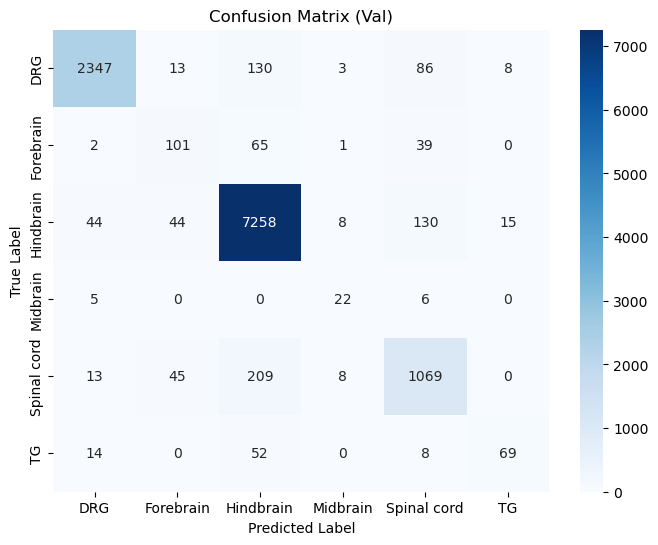

Val Macro ROC AUC: nan


/ictstr01/home/icb/ilia.navosha/tools/apps/micromamba/envs/jupyter/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/ictstr01/home/icb/ilia.navosha/tools/apps/micromamba/envs/jupyter/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [16]:
# ---------- Evaluation Metrics ----------
# Overall accuracy
train_acc = accuracy_score(gt_region_train, pred_region_train)
val_acc = accuracy_score(gt_region_val, pred_region_val)
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Val Accuracy:   {val_acc:.4f}\n")


# F1 score
train_f1 = f1_score(gt_region_train, pred_region_train, average="weighted")
val_f1 = f1_score(gt_region_val, pred_region_val, average="weighted")
print(f"Train F1: {train_f1:.4f}")
print(f"Val F1:   {val_f1:.4f}\n")

# Detailed classification report
print("Val Classification Report:")
print(classification_report(gt_region_val, pred_region_val))

# Confusion matrix
labels = np.unique(np.concatenate([gt_region_val, pred_region_val]))
cm = confusion_matrix(gt_region_val, pred_region_val, labels=labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix (Val)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Multiclass ROC AUC (one-vs-rest)
# Requires one-hot encoding of ground truth labels
from sklearn.preprocessing import label_binarize
classes = ohe.categories_[0]
gt_val_bin = label_binarize(gt_region_val, classes=classes)
try:
    roc_auc = roc_auc_score(gt_val_bin, probs_val, multi_class='ovr', average='macro')
    print(f"Val Macro ROC AUC: {roc_auc:.4f}")
except ValueError as e:
    print(f"ROC AUC could not be computed: {e}")

In [17]:
logits_test = predict_on_adata(
    test_adata,
    obsm_key="X_train_pca",
)

probs_test = softmax(logits_test, axis=1)

labels_test = probs_test.argmax(axis=1)

pred_region_test = le.inverse_transform(labels_test)

gt_region_test = test_adata.obs["Region"].values

test_acc = accuracy_score(
    gt_region_test,
    pred_region_test,
)

test_f1 = f1_score(
    gt_region_test,
    pred_region_test,
    average="weighted",
)

test_f1_macro = f1_score(
    gt_region_test,
    pred_region_test,
    average="macro",
)

print(f"Test accuracy:    {test_acc:.4f}")
print(f"Test weighted F1: {test_f1:.4f}")
print(f"Test macro F1:    {test_f1_macro:.4f}")

Test accuracy:    0.9762
Test weighted F1: 0.9742
Test macro F1:    0.5052


Test Classification Report:
              precision    recall  f1-score   support

         DRG       0.45      0.30      0.36        63
   Forebrain       1.00      0.60      0.75         5
   Hindbrain       0.98      0.99      0.99      3944
 Spinal cord       0.14      0.29      0.19         7
          TG       0.67      0.14      0.24        14

    accuracy                           0.98      4033
   macro avg       0.65      0.46      0.51      4033
weighted avg       0.97      0.98      0.97      4033



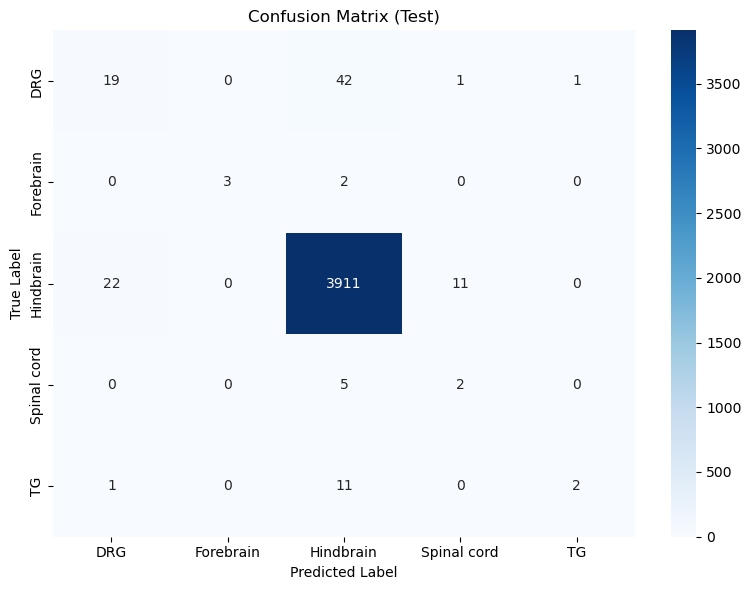

In [18]:
# Detailed classification report
print("Test Classification Report:")
print(classification_report(gt_region_test, pred_region_test))

# Confusion matrix
labels = np.unique(
    np.concatenate([gt_region_test, pred_region_test])
)

cm = confusion_matrix(
    gt_region_test,
    pred_region_test,
    labels=labels,
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
)

plt.title("Confusion Matrix (Test)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()